<a href="https://colab.research.google.com/github/AyhamSmaDi-DS/WA_Fn-UseC_-Telco-Customer-Churn-Project/blob/main/WA_Fn_UseC__Telco_Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


array([[<Axes: title={'center': 'SeniorCitizen'}>,
        <Axes: title={'center': 'tenure'}>],
       [<Axes: title={'center': 'MonthlyCharges'}>, <Axes: >]],
      dtype=object)

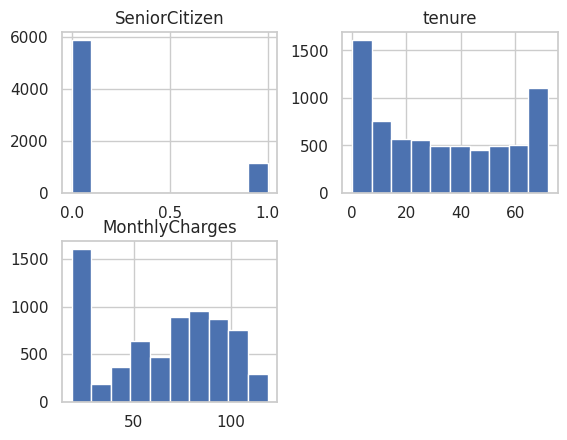

In [ ]:
df.hist()

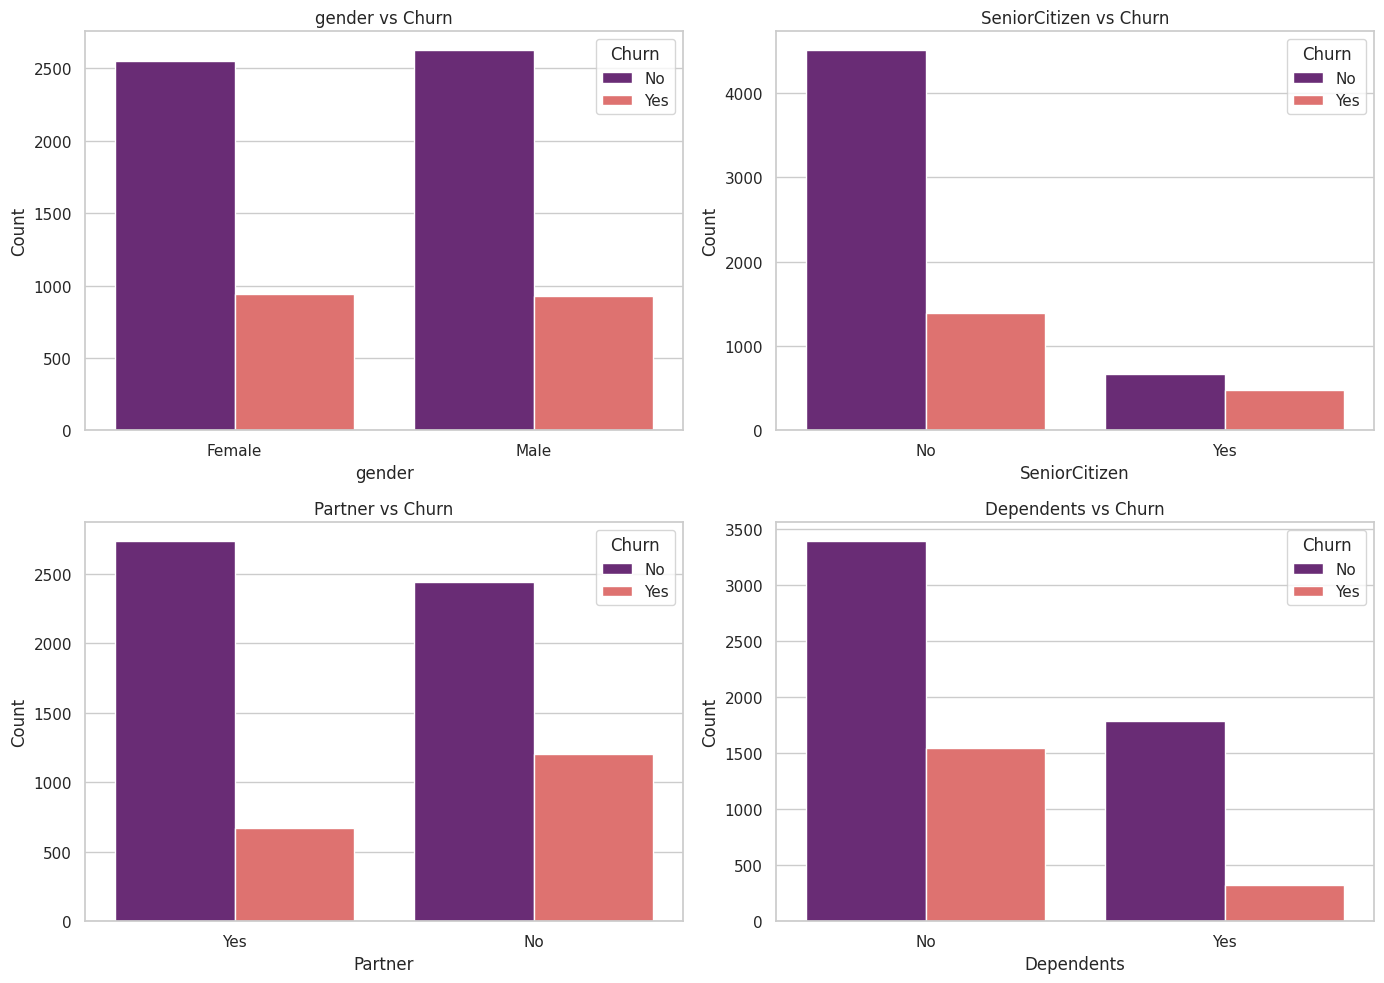

--- تحليل النسب المئوية للترك (Churn Rate) ---

النسبة المئوية لـ gender:
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

النسبة المئوية لـ SeniorCitizen:
Churn                 No        Yes
SeniorCitizen                      
No             76.393832  23.606168
Yes            58.318739  41.681261

النسبة المئوية لـ Partner:
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

النسبة المئوية لـ Dependents:
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. إعداد الثيم (Style)
sns.set_theme(style="whitegrid")

# 2. تجهيز نسخة للرسم (تحويل 0 و 1 لنصوص لجمالية الرسم)
df_viz = df.copy()
df_viz['SeniorCitizen'] = df_viz['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 3. تحديد أعمدة المجموعة الأولى
personal_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

# 4. إنشاء لوحة الرسم (Subplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 5. رسم كل عمود مقابل الـ Churn
for i, col in enumerate(personal_cols):
    sns.countplot(data=df_viz, x=col, hue='Churn', ax=axes[i], palette='magma')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show() # أو plt.savefig('personal_info.png') لو بدك تحفظها

# 6. حساب النسب المئوية (عشان الفصفصة الرقمية)
print("--- تحليل النسب المئوية للترك (Churn Rate) ---")
for col in personal_cols:
    cross = pd.crosstab(df_viz[col], df_viz['Churn'], normalize='index') * 100
    print(f"\nالنسبة المئوية لـ {col}:")
    print(cross)

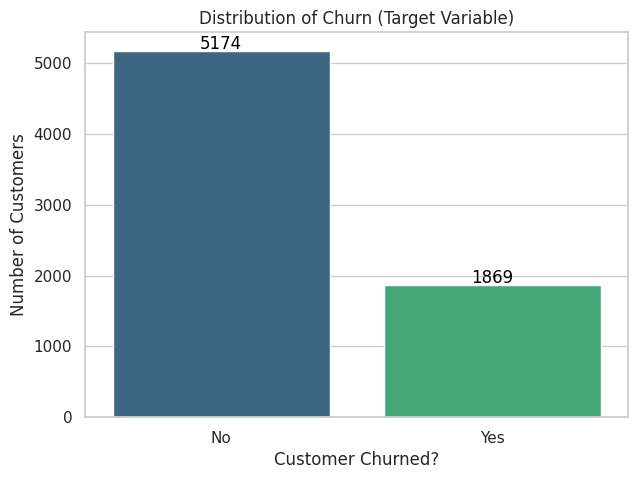

--- إحصائيات الهدف (Churn Statistics) ---
       Count  Percentage (%)
Churn                       
No      5174       73.463013
Yes     1869       26.536987


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إعداد الثيم
sns.set_theme(style="whitegrid")

# 2. رسم توزيع الـ Churn
plt.figure(figsize=(7, 5))
# hue='Churn' عشان نلون الأعمدة، و palette='viridis' لألوان احترافية
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis')

# إضافة الأرقام فوق كل عمود (حركة سينيور عشان الرسمة تكون مقروءة)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Customer Churned?')
plt.ylabel('Number of Customers')
plt.show()

# 3. حساب الأرقام والنسب المئوية
churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100

print("--- إحصائيات الهدف (Churn Statistics) ---")
summary_df = pd.DataFrame({
    'Count': churn_counts,
    'Percentage (%)': churn_percentages
})
print(summary_df)

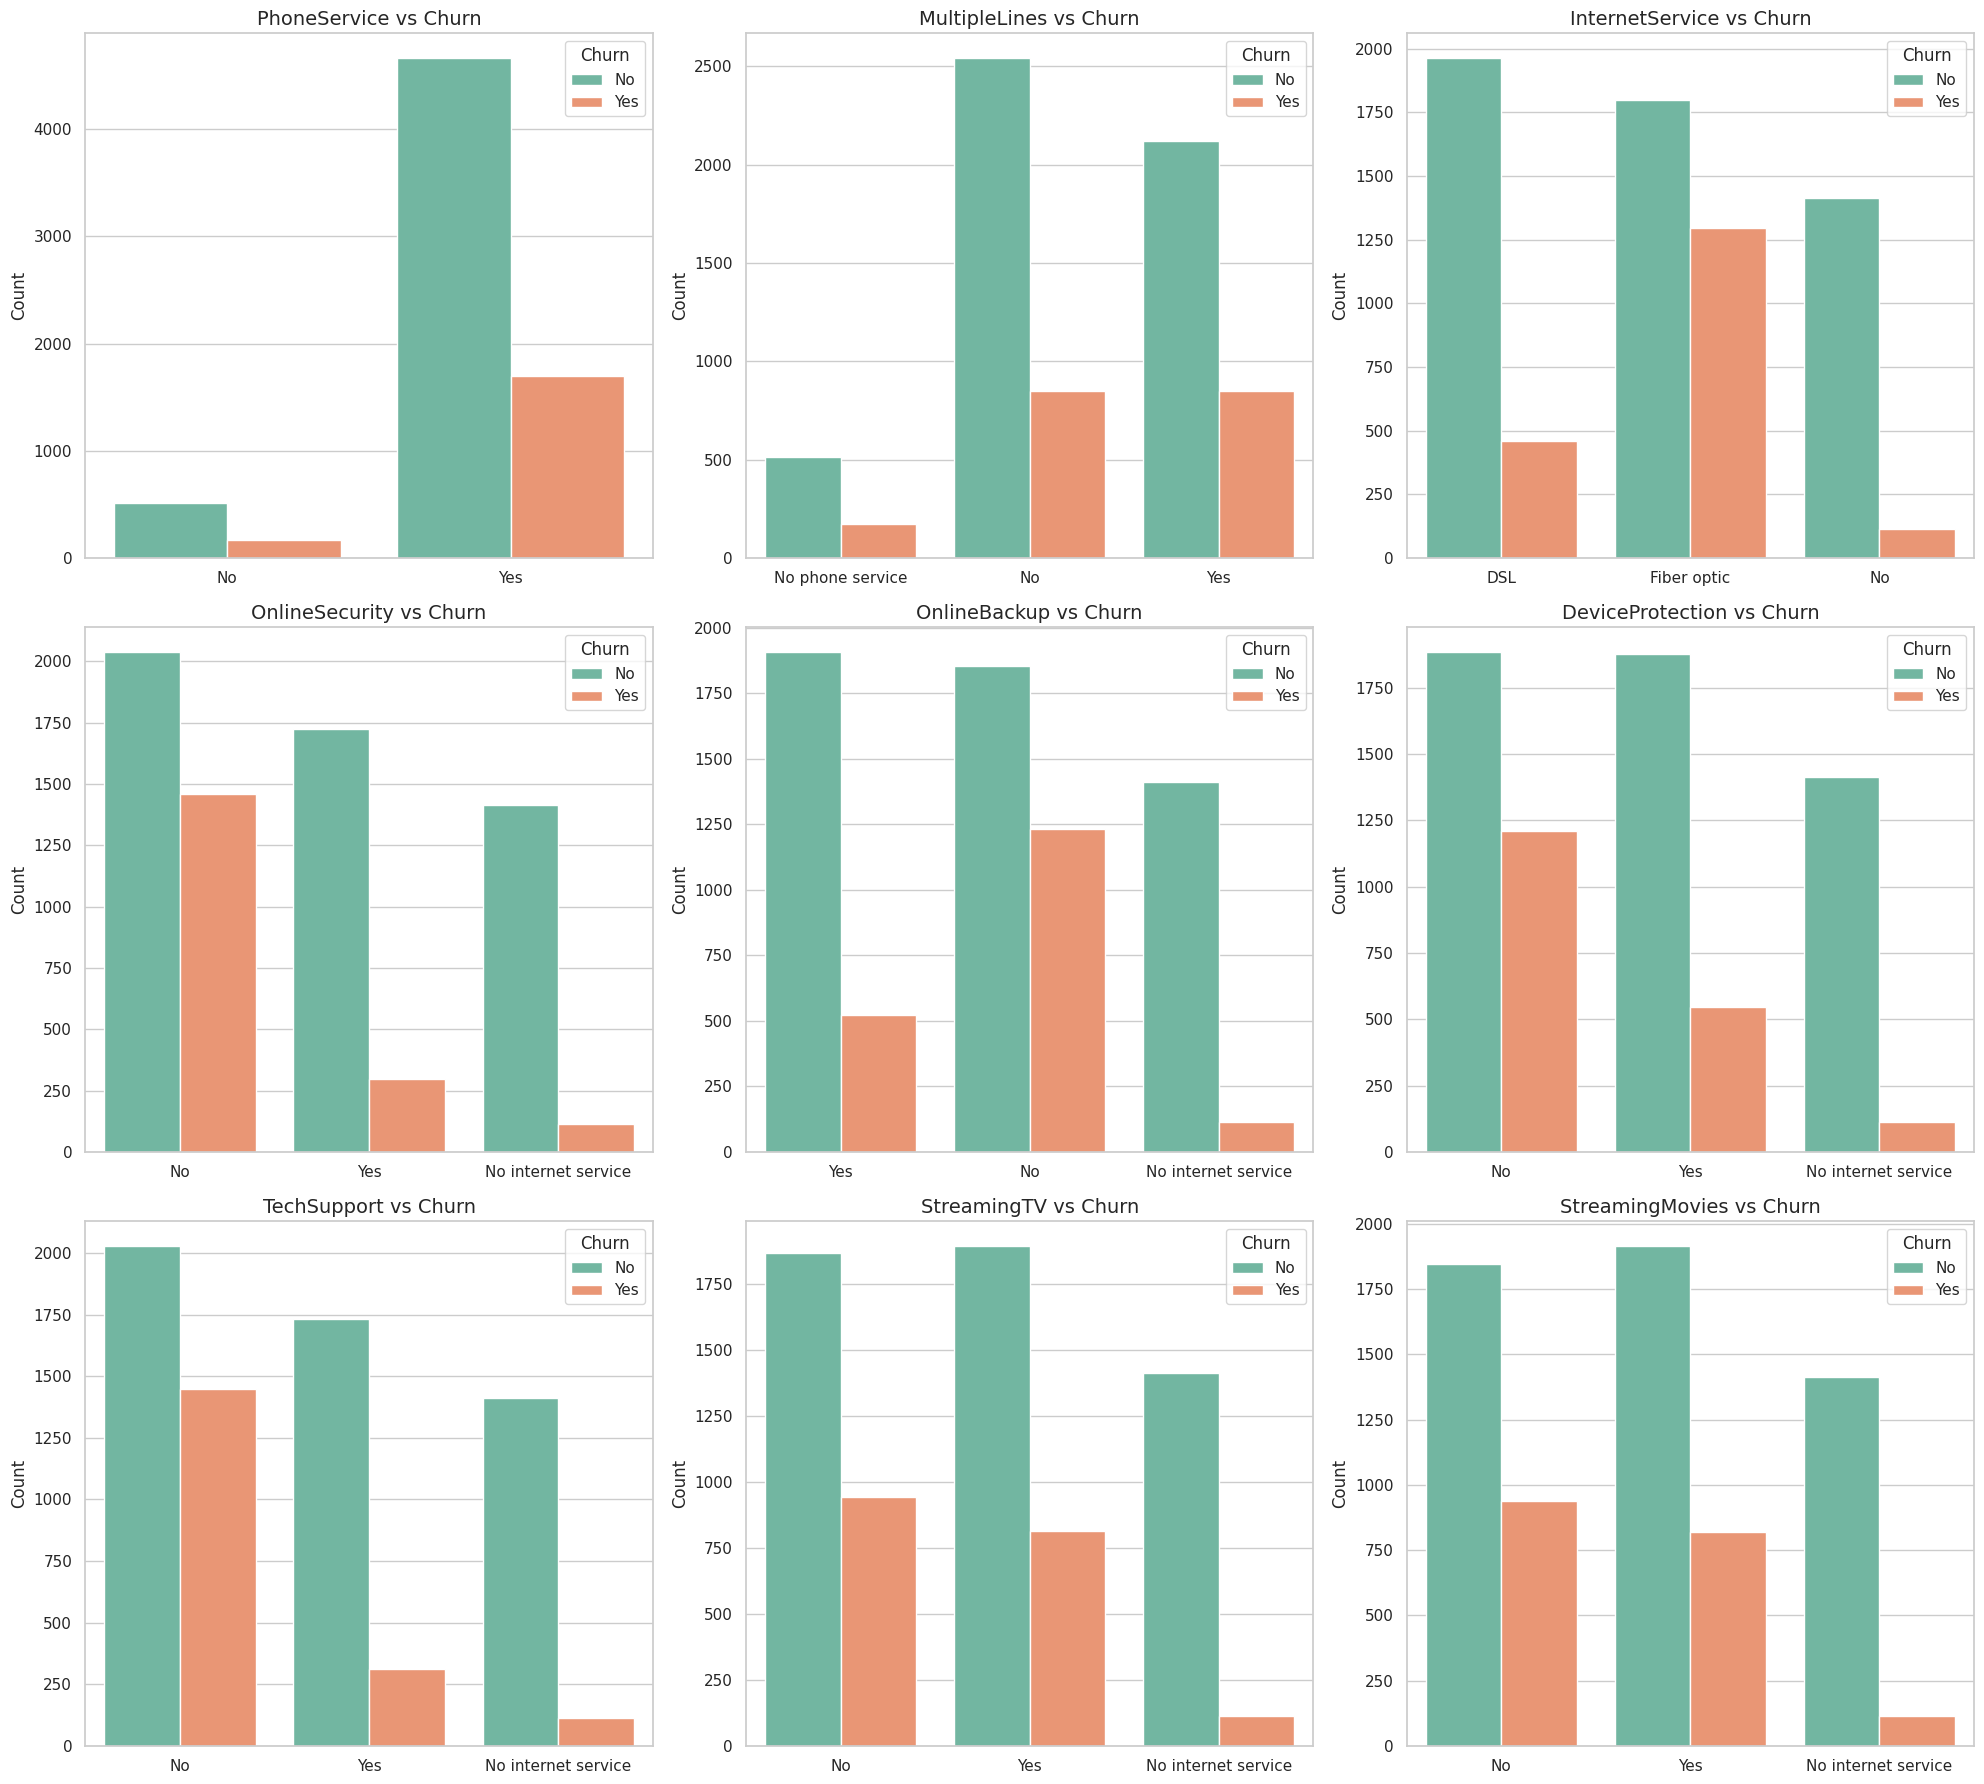


--- PhoneService vs Churn ---
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

--- MultipleLines vs Churn ---
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896

--- InternetService vs Churn ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

--- OnlineSecurity vs Churn ---
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

--- OnlineBackup vs Churn ---
Churn                       No        Yes
OnlineBackup                             
No                  

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحديد أعمدة الخدمات
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(services_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Churn', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# لحساب النسب الدقيقة لكل خدمة
for col in services_cols:
    print(f"\n--- {col} vs Churn ---")
    print(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)

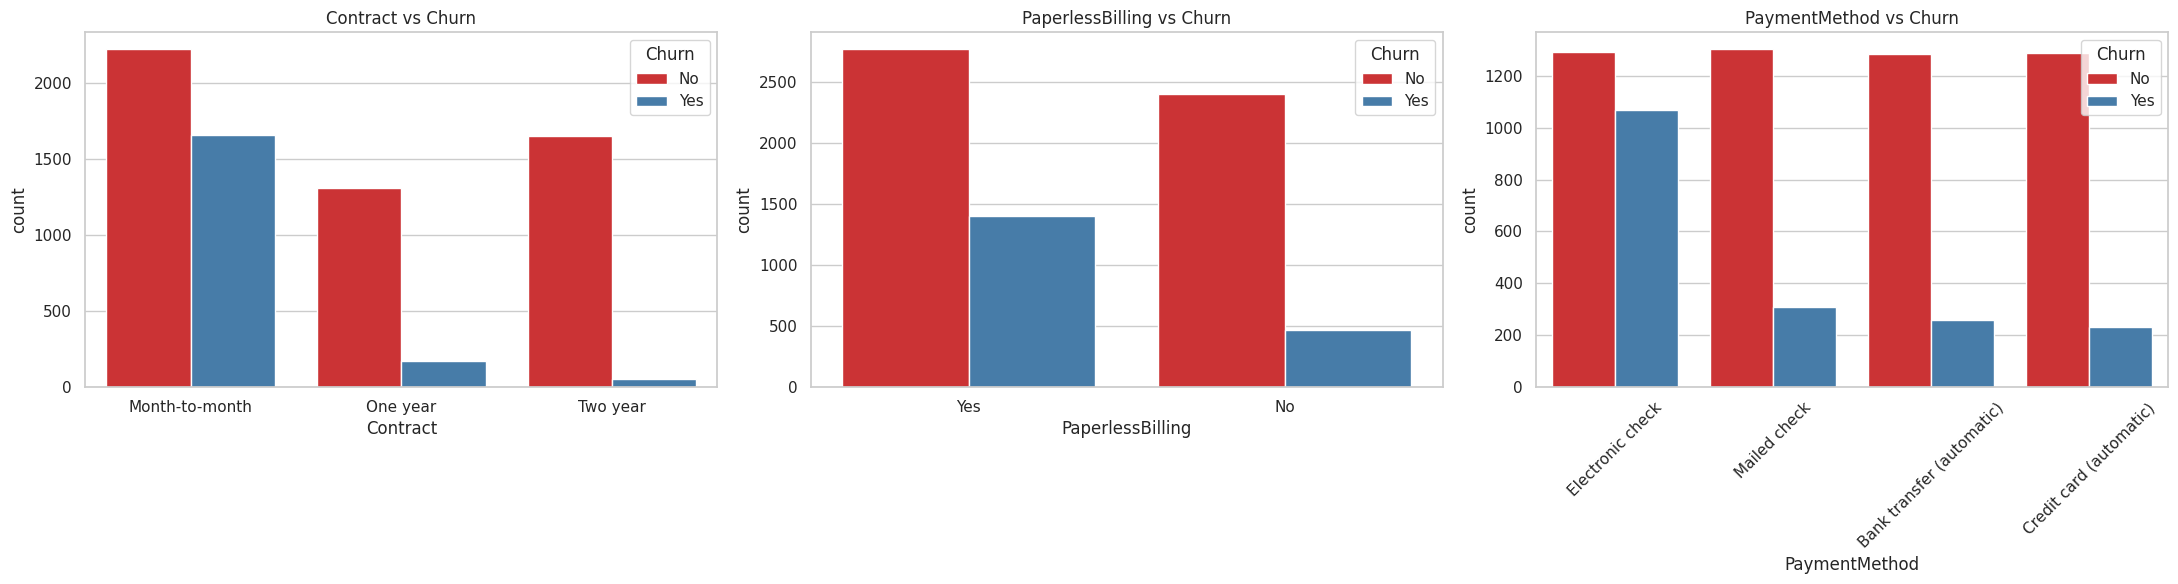

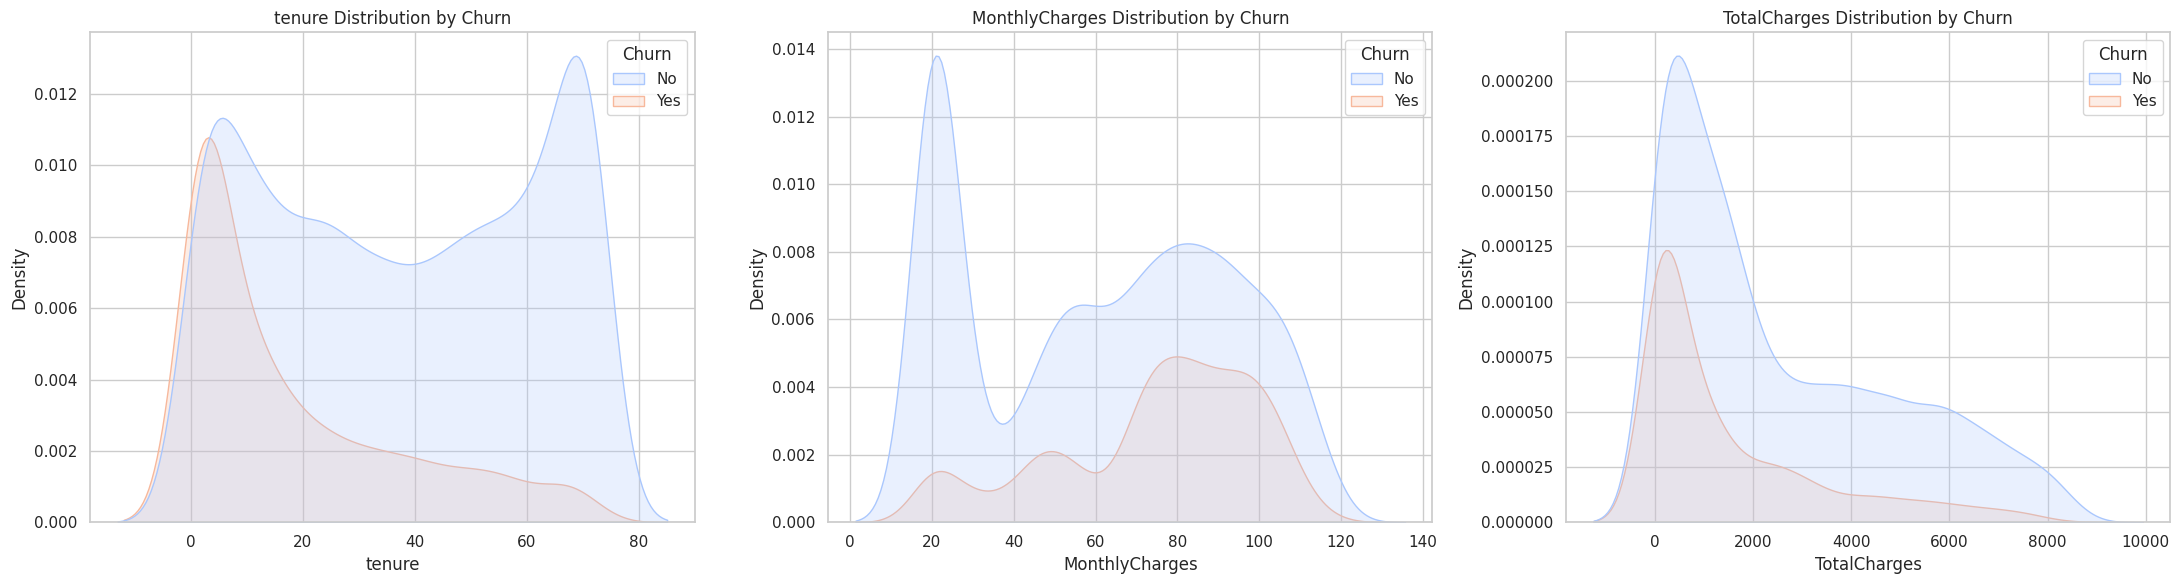

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تنظيف عمود TotalCharges (لأن فيه فراغات مخفية)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

sns.set_theme(style="whitegrid")

# 1. رسم العقود وطرق الدفع
cat_financials = ['Contract', 'PaperlessBilling', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, col in enumerate(cat_financials):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col} vs Churn')
    if col == 'PaymentMethod': axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. رسم التوزيعات الرقمية (tenure, MonthlyCharges)
num_financials = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, col in enumerate(num_financials):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.show()

In [ ]:
# كود لكشف التكرار في القيم النصية
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if col != 'customerID': # بنستثني الـ ID لأنه فريد لكل شخص
        print(f"القيم في عمود {col}: {df[col].unique()}")

القيم في عمود gender: ['Female' 'Male']
القيم في عمود Partner: ['Yes' 'No']
القيم في عمود Dependents: ['No' 'Yes']
القيم في عمود PhoneService: ['No' 'Yes']
القيم في عمود MultipleLines: ['No phone service' 'No' 'Yes']
القيم في عمود InternetService: ['DSL' 'Fiber optic' 'No']
القيم في عمود OnlineSecurity: ['No' 'Yes' 'No internet service']
القيم في عمود OnlineBackup: ['Yes' 'No' 'No internet service']
القيم في عمود DeviceProtection: ['No' 'Yes' 'No internet service']
القيم في عمود TechSupport: ['No' 'Yes' 'No internet service']
القيم في عمود StreamingTV: ['No' 'Yes' 'No internet service']
القيم في عمود StreamingMovies: ['No' 'Yes' 'No internet service']
القيم في عمود Contract: ['Month-to-month' 'One year' 'Two year']
القيم في عمود PaperlessBilling: ['Yes' 'No']
القيم في عمود PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
القيم في عمود Churn: ['No' 'Yes']


# **Preprocessing**

In [ ]:

df_cleaned = df.copy()

# 1. حذف الـ ID (Noise Removal)
df_cleaned.drop('customerID', axis=1, inplace=True)

# 2. حل مشكلة TotalCharges (The "Space" Trap)
# errors='coerce' هي المفتاح هون لتحويل الفراغات لـ NaNs
df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce')

# 3. توحيد القيم النصية (Redundancy Removal)
# رح نمسح "No internet service" و "No phone service" ونخليها "No"
replace_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in replace_cols:
    df_cleaned[col] = df_cleaned[col].replace({'No internet service': 'No', 'No phone service': 'No'})

# 4. هندسة الميزة الجديدة (TotalServices)
# بنعد كم "Yes" عند العميل في الخدمات الستة الأساسية
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_cleaned['TotalServices'] = (df_cleaned[services] == 'Yes').sum(axis=1)

# 5. تحويل SeniorCitizen لـ Object
df_cleaned['SeniorCitizen'] = df_cleaned['SeniorCitizen'].astype('object')
##############################################################

print("🚀 ميزة 'صدمة الفاتورة' جاهزة.. هاي رح تطلع التوب 1 في الـ Feature Importance!")
# 6. فحص النتائج النهائية لهي المرحلة
print("--- فحص القيم المفقودة (بعد تحويل TotalCharges) ---")
print(df_cleaned.isnull().sum())
print("\n--- شكل الداتا المبدئي بعد إضافة الميزة الجديدة ---")
print(df_cleaned[['TotalServices', 'TotalCharges']].head())

🚀 ميزة 'صدمة الفاتورة' جاهزة.. هاي رح تطلع التوب 1 في الـ Feature Importance!
--- فحص القيم المفقودة (بعد تحويل TotalCharges) ---
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
TotalServices        0
dtype: int64

--- شكل الداتا المبدئي بعد إضافة الميزة الجديدة ---
   TotalServices  TotalCharges
0              1         29.85
1              2       1889.50
2              2        108.15
3              3       1840.75
4              0        151.65


In [ ]:
# حذف الأسطر الـ 11 اللي طلعت NaN في TotalCharges
df_cleaned.dropna(subset=['TotalCharges'], inplace=True)

In [ ]:
# 2. خطوة "احتياطية" دايماً بنعملها كـ Senior (حذف التكرار إن وجد)
df_cleaned.drop_duplicates(inplace=True)

# **Split**


In [ ]:
# 1. تحديد الميزات والهدف
# X هي كل الداتا بدون عمود الـ Churn
X = df_cleaned.drop('Churn', axis=1)

# y هو عمود الـ Churn فقط
y = df_cleaned['Churn']

# 2. عملية التقسيم
# test_size=0.2 يعني 20% للاختبار
# random_state=42 عشان نضمن إن التقسيم يضل نفسه كل ما تشغل الكود (Reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. فحص الأحجام بعد التقسيم
print(f"حجم بيانات التدريب (X_train): {X_train.shape}")
print(f"حجم بيانات الاختبار (X_test): {X_test.shape}")

حجم بيانات التدريب (X_train): (5608, 20)
حجم بيانات الاختبار (X_test): (1402, 20)


In [ ]:
# فحص نسبة الـ Churn في التدريب والاختبار
print("نسبة الـ Churn في التدريب (y_train):\n", y_train.value_counts(normalize=True))
print("\nنسبة الـ Churn في الاختبار (y_test):\n", y_test.value_counts(normalize=True))

نسبة الـ Churn في التدريب (y_train):
 Churn
No     0.735021
Yes    0.264979
Name: proportion, dtype: float64

نسبة الـ Churn في الاختبار (y_test):
 Churn
No     0.735378
Yes    0.264622
Name: proportion, dtype: float64


# **Encoding and Scaling**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# تعريف المحول
le = LabelEncoder()

# التعلم من التدريب وتطبيقه على الطرفين
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print("ترتيب الفئات في الهدف:", le.classes_) # [No, Yes] يعني No=0 و Yes=1

ترتيب الفئات في الهدف: ['No' 'Yes']


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. تحديد الأعمدة النصية اللي حددناهم سوا
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# 2. بناء المحول (Transformer)
# drop='if_binary' بتعمل Label Encoding للثنائي و One-Hot للمتعدد.. ضربة معلم!
# remainder='passthrough' عشان تترك أعمدة الأرقام (tenure, charges) زي ما هي وما تحذفها
ct = ColumnTransformer(transformers=[
    ('encoder', OneHotEncoder(drop='if_binary', sparse_output=False), cat_cols)
], remainder='passthrough')

# 3. التطبيق (Fit على الترين فقط، ثم Transform للطرفين)
X_train_encoded = ct.fit_transform(X_train)
X_test_encoded = ct.transform(X_test)

# 4. تحويل النتيجة لـ DataFrame (عشان نعرف نقرأها)
# هون بنستخرج أسماء الأعمدة الجديدة اللي طلعت من الـ One-Hot
new_columns = ct.get_feature_names_out()
X_train_final = pd.DataFrame(X_train_encoded, columns=new_columns)
X_test_final = pd.DataFrame(X_test_encoded, columns=new_columns)

print(f"عدد الأعمدة قبل: {X_train.shape[1]}")
print(f"عدد الأعمدة بعد الـ Encoding: {X_train_final.shape[1]}")

عدد الأعمدة قبل: 20
عدد الأعمدة بعد الـ Encoding: 27


In [ ]:
# اطبع كل أسامي الأعمدة عشان تشوف الأسامي الجديدة بعينك
print(X_train_final.columns.tolist())

['encoder__gender_Male', 'encoder__SeniorCitizen_1', 'encoder__Partner_Yes', 'encoder__Dependents_Yes', 'encoder__PhoneService_Yes', 'encoder__MultipleLines_Yes', 'encoder__InternetService_DSL', 'encoder__InternetService_Fiber optic', 'encoder__InternetService_No', 'encoder__OnlineSecurity_Yes', 'encoder__OnlineBackup_Yes', 'encoder__DeviceProtection_Yes', 'encoder__TechSupport_Yes', 'encoder__StreamingTV_Yes', 'encoder__StreamingMovies_Yes', 'encoder__Contract_Month-to-month', 'encoder__Contract_One year', 'encoder__Contract_Two year', 'encoder__PaperlessBilling_Yes', 'encoder__PaymentMethod_Bank transfer (automatic)', 'encoder__PaymentMethod_Credit card (automatic)', 'encoder__PaymentMethod_Electronic check', 'encoder__PaymentMethod_Mailed check', 'remainder__tenure', 'remainder__MonthlyCharges', 'remainder__TotalCharges', 'remainder__TotalServices']


In [ ]:
# حذف كلمة 'encoder__' و 'remainder__' من كل الأسامي بضربة وحدة
X_train_final.columns = [c.split('__')[-1] for c in X_train_final.columns]
X_test_final.columns = [c.split('__')[-1] for c in X_test_final.columns]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# هسا بتقدر تستخدم أساميك الأصلية عادي
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']
X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

print("✨ تم تنظيف الأسماء وعمل الـ Scaling بنجاح!")

✨ تم تنظيف الأسماء وعمل الـ Scaling بنجاح!


In [ ]:
print("إجمالي القيم المفقودة في التدريب:", X_train_final.isnull().sum().sum())
print("إجمالي القيم المفقودة في الاختبار:", X_test_final.isnull().sum().sum())

إجمالي القيم المفقودة في التدريب: 0
إجمالي القيم المفقودة في الاختبار: 0


In [ ]:
# إذا طلع عندك أي عمود نوعه 'object' معناه في مشكلة بالـ Encoding
print("الأنواع الموجودة في الداتا:", X_train_final.dtypes.unique())

الأنواع الموجودة في الداتا: [dtype('float64')]


In [ ]:
# المتوسط لازم يكون قريب جداً من الصفر (0) والانحراف المعياري قريب من الواحد (1)
print("متوسط عمود tenure بعد الـ Scaling:", round(X_train_final['tenure'].mean(), 2))
print("الانحراف المعياري لـ tenure:", round(X_train_final['tenure'].std(), 2))

متوسط عمود tenure بعد الـ Scaling: 0.0
الانحراف المعياري لـ tenure: 1.0


In [ ]:
print("متوسط tenure في التيست:", round(X_test_final['tenure'].mean(), 2))
print("انحراف tenure في التيست:", round(X_test_final['tenure'].std(), 2))

متوسط tenure في التيست: 0.02
انحراف tenure في التيست: 1.02


In [ ]:
print(f"X_train: {X_train_final.shape} | y_train: {y_train.shape}")
print(f"X_test: {X_test_final.shape} | y_test: {y_test.shape}")

X_train: (5608, 27) | y_train: (5608,)
X_test: (1402, 27) | y_test: (1402,)


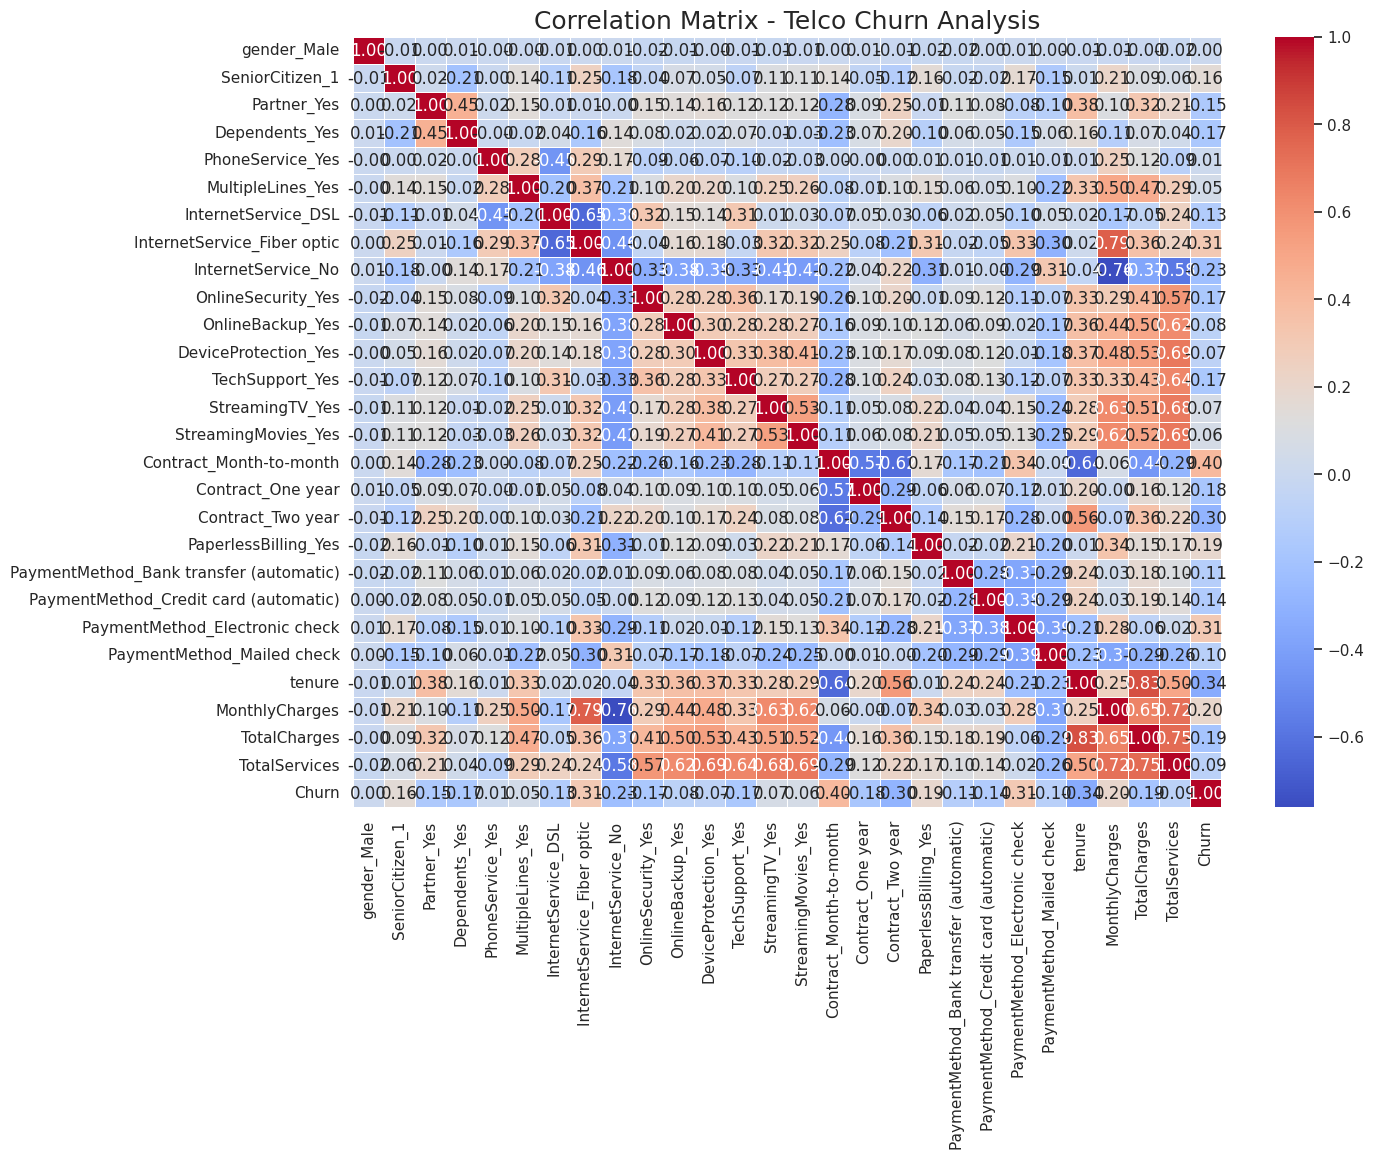


--- Numerical Correlation with Target (Churn) ---
                                            Churn
Churn                                    1.000000
Contract_Month-to-month                  0.402895
InternetService_Fiber optic              0.312184
PaymentMethod_Electronic check           0.308742
MonthlyCharges                           0.197180
PaperlessBilling_Yes                     0.194910
SeniorCitizen_1                          0.159496
StreamingTV_Yes                          0.067130
StreamingMovies_Yes                      0.061069
MultipleLines_Yes                        0.050951
PhoneService_Yes                         0.013230
gender_Male                              0.003778
DeviceProtection_Yes                    -0.066381
OnlineBackup_Yes                        -0.076339
TotalServices                           -0.085185
PaymentMethod_Mailed check              -0.099377
PaymentMethod_Bank transfer (automatic) -0.113495
InternetService_DSL                     -0.131699

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. دمج البيانات للحساب
plot_df = X_train_final.copy()
plot_df['Churn'] = y_train # Removed .values as y_train is already a NumPy array

# 2. حساب مصفوفة الارتباط
corr_matrix = plot_df.corr()

# 3. رسم الـ Heatmap (المربعات)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Telco Churn Analysis', fontsize=18)
plt.show()

# 4. استخراج جدول الأرقام للارتباط مع Churn تحديداً
churn_correlations = corr_matrix['Churn'].sort_values(ascending=False).to_frame()
print("\n--- Numerical Correlation with Target (Churn) ---")
print(churn_correlations)

In [ ]:
print("Billing_Shock_Index" in X_train_final.columns)

False


--- تقرير الأداء (Classification Report) ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1031
           1       0.51      0.78      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.75      0.76      1402



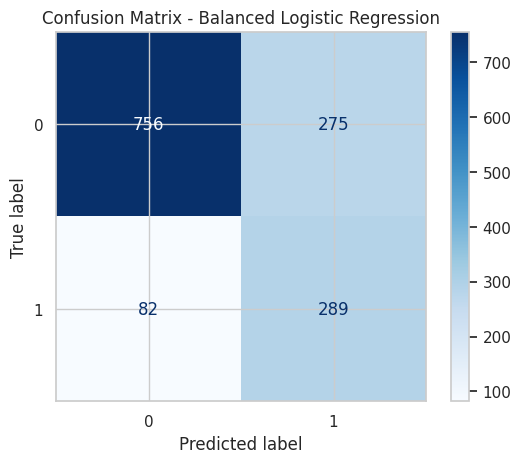

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. تعريف الموديل مع ميزة الموازنة التلقائية
# class_weight='balanced' هي اللي رح تحل مشكلة الـ Imbalance رياضياً
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# 2. التدريب (Learning)
lr_model.fit(X_train_final, y_train)

# 3. التوقع (Prediction)
y_pred = lr_model.predict(X_test_final)

# 4. التقييم (Evaluation)
print("--- تقرير الأداء (Classification Report) ---")
print(classification_report(y_test, y_pred))

# 5. رسم الـ Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. تحديد "شبكة" الباراميترز اللي بدنا نجربها
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],            # جرب من الصغير للكبير
    'penalty': ['l1', 'l2'],                 # جرب النوعين
    'solver': ['liblinear']                  # liblinear ممتاز للأوزان الصغيرة والـ L1
}

# 2. بناء الـ Grid Search
# cv=5 يعني رح يعمل 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='f1',                            # ركزنا على الـ F1 لأنه بوزن بين الـ Recall والـ Precision
    cv=5,
    verbose=1
)

# 3. التدريب (هون الموديل رح يتدرب 50 مرة! 5 خيارات C * خيارين penalty * 5 طيات CV)
grid_search.fit(X_train_final, y_train)

# 4. استخراج "الخلطة السرية" (أفضل باراميترز)
print("أفضل باراميترز لقاها الموديل:", grid_search.best_params_)

# 5. التوقع باستخدام أفضل نسخة من الموديل
best_lr = grid_search.best_estimator_
y_pred_tuned = best_lr.predict(X_test_final)

# 6. فحص النتائج الجديدة
print("\n--- تقرير الأداء بعد الـ Tuning ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
أفضل باراميترز لقاها الموديل: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}

--- تقرير الأداء بعد الـ Tuning ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1031
           1       0.51      0.77      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.76      0.71      1402
weighted avg       0.80      0.75      0.76      1402



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. بناء الموديل
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. التدريب
rf_model.fit(X_train_final, y_train)

# 3. التوقع
y_pred_rf = rf_model.predict(X_test_final)

# 4. النتائج
print("--- أداء الـ Random Forest (قبل التوننق) ---")
print(classification_report(y_test, y_pred_rf))

--- أداء الـ Random Forest (قبل التوننق) ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1031
           1       0.64      0.45      0.53       371

    accuracy                           0.79      1402
   macro avg       0.73      0.68      0.69      1402
weighted avg       0.77      0.79      0.77      1402



In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. تحديد شبكة الباراميترز (البرغي اللي رح نلفه)
param_grid_rf = {
    'n_estimators': [100, 200],              # عدد الأشجار في الغابة
    'max_depth': [5, 10, 15],                # بنحدد العمق عشان نمنع الحفظ (Overfitting)
    'min_samples_leaf': [2, 5, 10],          # أقل عدد زباين في كل ورقة شجر
    'class_weight': ['balanced']             # الموازنة ضرورية جداً
}

# 2. بناء الـ Grid Search
# ركزنا على scoring='f1' عشان نضمن توازن بين الدقة والصيد
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1 # لاستخدام كل قدرة المعالج وتسريع العملية
)

# 3. التدريب (هون رح يطول شوي لأنه بجرب احتمالات كثيرة)
grid_rf.fit(X_train_final, y_train)

# 4. أفضل خلطة لقاها
print("أفضل إعدادات للغابة:", grid_rf.best_params_)

# 5. التوقع بالنسخة "المروضة"
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_final)

# 6. النتائج النهائية
print("\n--- أداء الـ Random Forest بعد الترويض ---")
print(classification_report(y_test, y_pred_best_rf))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
أفضل إعدادات للغابة: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}

--- أداء الـ Random Forest بعد الترويض ---
              precision    recall  f1-score   support

           0       0.89      0.78      0.84      1031
           1       0.55      0.74      0.64       371

    accuracy                           0.77      1402
   macro avg       0.72      0.76      0.74      1402
weighted avg       0.80      0.77      0.78      1402



/tmp/ipykernel_1048/441960782.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


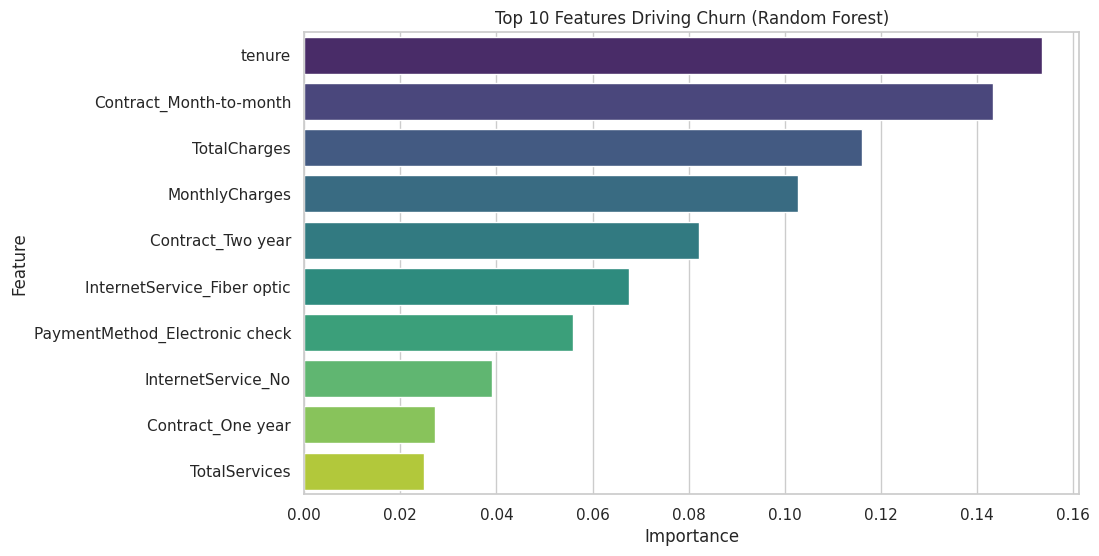

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استخراج الأهمية من الموديل المروض
importances = best_rf.feature_importances_
feature_names = X_train_final.columns

# 2. تنظيمهم في جدول
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. رسم البياني (أهم 10 ميزات)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features Driving Churn (Random Forest)')
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 1. حساب الوزن المثالي للفئة الأقلية (Yes)
# هاد الرقم بخلي الموديل يعطي أهمية أكبر للناس اللي بتترك
ratio = float(y_train.tolist().count(0) / y_train.tolist().count(1))

# 2. تعريف شبكة البحث (The Grid)
# اخترت لك قيم ذكية بتوازن بين السرعة وقوة لقط الأنماط
param_grid_xgb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'gamma': [0, 0.1, 0.2],
    'scale_pos_weight': [ratio] # الوزن اللي حسبناه فوق
}

# 3. بناء الـ Grid Search
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 4. التدريب (هون الموديل رح "يعصر" الداتا)
xgb_grid.fit(X_train_final, y_train)

# 5. استخراج النتائج
print("أفضل خلطة للـ XGBoost:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test_final)

# 6. التقييم النهائي
print("\n--- تقرير الأداء النهائي (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
أفضل خلطة للـ XGBoost: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 2.7738896366083448}

--- تقرير الأداء النهائي (XGBoost) ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1031
           1       0.52      0.79      0.63       371

    accuracy                           0.75      1402
   macro avg       0.72      0.77      0.72      1402
weighted avg       0.81      0.75      0.77      1402



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:04:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Figure size 800x600 with 0 Axes>

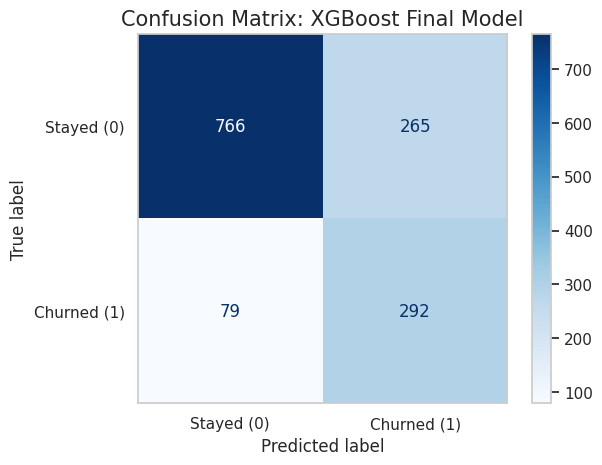

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. التوقع باستخدام الموديل النهائي (تأكد إنك استخدمت best_xgb)
y_pred_xgb = best_xgb.predict(X_test_final)

# 2. حساب المصفوفة
cm = confusion_matrix(y_test, y_pred_xgb)

# 3. رسم المصفوفة بشكل أنيق
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed (0)', 'Churned (1)'])

# استخدام اللون الأزرق (Blues) لسهولة القراءة
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix: XGBoost Final Model', fontsize=15)
plt.grid(False) # عشان الرسمة تطلع نظيفة بدون خطوط شبكة
plt.show()

/tmp/ipykernel_1048/636077667.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_imp_df.head(12), palette='magma')


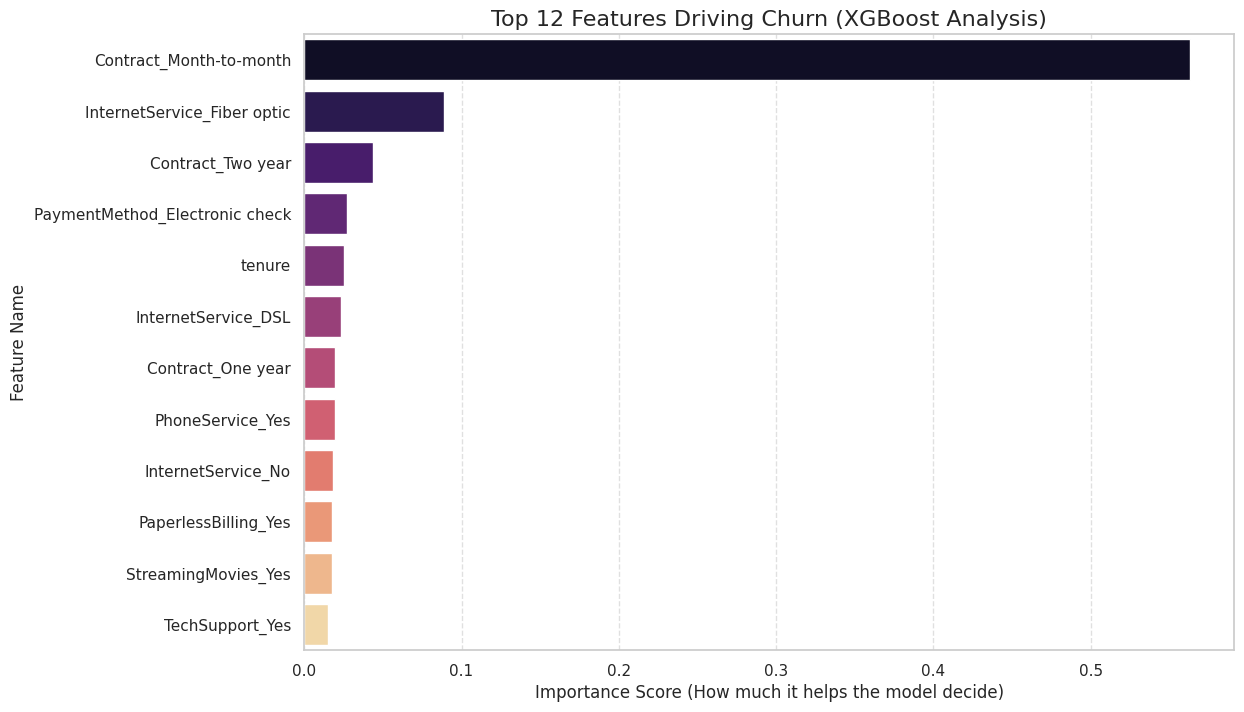

أهم 5 ميزات أثرت على قرار الموديل:
                           Feature  Importance
15         Contract_Month-to-month    0.563187
7      InternetService_Fiber optic    0.088602
17               Contract_Two year    0.043649
21  PaymentMethod_Electronic check    0.027186
23                          tenure    0.025153


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. استخراج أهمية الميزات من الموديل المروض (best_xgb)
xgb_importances = best_xgb.feature_importances_
feature_names = X_train_final.columns

# 2. تنظيم البيانات في DataFrame لسهولة الترتيب
xgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
})

# 3. ترتيب الميزات تنازلياً (من الأهم للأقل)
xgb_imp_df = xgb_imp_df.sort_values(by='Importance', ascending=False)

# 4. رسم بياني لأهم 12 ميزة (Top 12) باستخدام الوان Magma الجذابة
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_imp_df.head(12), palette='magma')

# إضافة لمسات جمالية للرسمة
plt.title('Top 12 Features Driving Churn (XGBoost Analysis)', fontsize=16)
plt.xlabel('Importance Score (How much it helps the model decide)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# عرض الرسمة
plt.show()

# 5. طباعة أول 5 ميزات بالأرقام للتأكيد
print("أهم 5 ميزات أثرت على قرار الموديل:")
print(xgb_imp_df.head(5))

In [ ]:
import joblib

# 1. حفظ الموديل النهائي (XGBoost)
# 'final_xgb_model.pkl' هو اسم الملف اللي رح يطلع عندك
joblib.dump(best_xgb, 'final_churn_model_xgb.pkl')

# 2. حفظ الـ Scaler (ضروري جداً لمعالجة البيانات الجديدة مستقبلاً)
# تأكد إن اسم المتغير عندك 'scaler' (أو الاسم اللي استخدمته في الـ Preprocessing)
joblib.dump(scaler, 'data_scaler.pkl')

print("✅ تم الحفظ بنجاح!")
print("الملفات الآن موجودة في مجلد المشروع وجاهزة للنقل.")

✅ تم الحفظ بنجاح!
الملفات الآن موجودة في مجلد المشروع وجاهزة للنقل.
